# Parameter Identification with Constraints (Python)
This notebook converts the Julia parameter identification workflow into Python. We model an LCL circuit, generate noisy data, and identify circuit parameters using both unconstrained and constrained optimization.

In [32]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize, LinearConstraint

np.random.seed(14588)

We study the circuit defined by the ODE system:

\[
\frac{d}{dt} \begin{bmatrix} i_1(t) \\ i_2(t) \\ v_C(t) \end{bmatrix} =
\begin{bmatrix} -(R_1+R_2)/L_1 & R_3/L_1 & -1/L_1 \\ R_3/L_2 & -(R_2+R_3)/L_2 & 1/L_2 \\ 1/C & -1/C & 0 \end{bmatrix}
\begin{bmatrix} i_1(t) \\ i_2(t) \\ v_C(t) \end{bmatrix} +
\begin{bmatrix} 1/L_1 \\ 0 \\ 0 \end{bmatrix} v(t)
\]

Only the input current $i_1(t)$ is measured.

In [33]:
# True circuit parameters
R1 = 0.5
R2 = 2.0
R3 = 1.0
L1 = 10e-3
L2 = 50e-3
C = 500e-6
v_in = 10.0

x0 = [0.0, 0.0, 0.0]
tspan = (0.0, 0.1)
t_eval = np.arange(tspan[0], tspan[1] + 1e-12, 0.0001)


def circuit_dynamics(t, x, params):
    R1_, R2_, R3_, L1_, L2_, C_ = params
    i1, i2, vC = x
    di1 = (-(R1_ + R2_) * i1 + R3_ * i2 - vC + v_in) / L1_
    di2 = (R3_ * i1 - (R3_ + R2_) * i2 + vC) / L2_
    dvC = (i1 - i2) / C_
    return [di1, di2, dvC]

sol = solve_ivp(lambda t, x: circuit_dynamics(t, x, [R1, R2, R3, L1, L2, C]), tspan, x0, t_eval=t_eval, vectorized=False)

t = sol.t
x = sol.y
sigma = 0.05
y = x + sigma * np.random.randn(*x.shape)

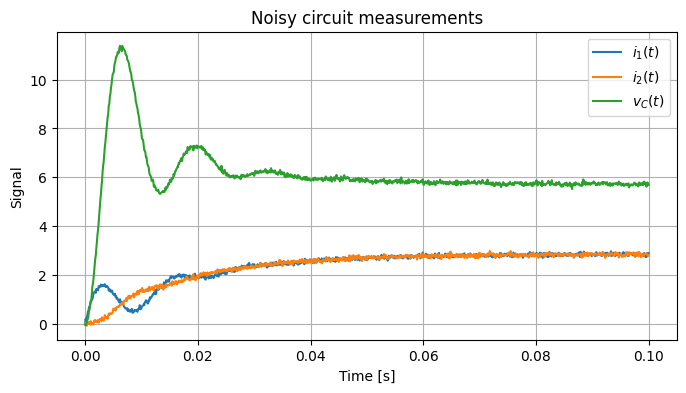

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(t, y[0, :], label=r'$i_1(t)$')
plt.plot(t, y[1, :], label=r'$i_2(t)$')
plt.plot(t, y[2, :], label=r'$v_C(t)$')
plt.xlabel('Time [s]')
plt.ylabel('Signal')
plt.title('Noisy circuit measurements')
plt.legend()
plt.grid(True)
plt.show()

Define the training model with unknown parameter vector $w = [R_1, R_2, R_3, L_1, L_2, C]$ and a cost function using only the measured input current.

In [ ]:
def simulate_circuit(w):
    # Ensure parameter vector is 1D float array
    w = np.asarray(w, dtype=float).ravel()
    # Try integration and validate the result shape
    try:
        sol = solve_ivp(lambda t, x: circuit_dynamics(t, x, w), tspan, x0, t_eval=t_eval, vectorized=False)
    except Exception:
        # return an invalid-shaped array to indicate failure
        return np.full((3, 0), np.nan)

    y_sol = sol.y
    # If solver returned a 1D array, reshape to (n_states, n_time_points)
    if y_sol.ndim == 1:
        y_sol = y_sol.reshape((-1, sol.t.size))

    # Validate dimensions
    if y_sol.ndim != 2 or y_sol.shape[0] != 3 or y_sol.shape[1] != t_eval.size:
        return np.full((3, 0), np.nan)

    # Also check solver success
    if not getattr(sol, "success", True):
        return np.full((3, 0), np.nan)

    return y_sol


def cost_function(w):
    x_pred = simulate_circuit(w)
    # If integration failed or returned unexpected shape, penalize heavily
    if x_pred.ndim != 2 or x_pred.shape[1] != t_eval.size or np.isnan(x_pred).any():
        return 1e12
    return float(np.sum((y[0, :] - x_pred[0, :]) ** 2)) # Only compare the first state (i1) as we have measurements for that state only

w0 = np.ones(6) #initial guess for the parameters as 1.0 as a arbitrary value

First attempt: unconstrained optimization using BFGS. This may fail or return unstable parameters because the search can explore invalid values.

In [36]:
res_unconstrained = minimize(cost_function, w0, method='BFGS', options={'disp': True})
res_unconstrained

         Current function value: 3870.789219
         Iterations: 0
         Function evaluations: 43
         Gradient evaluations: 6


C:\Users\27abd\AppData\Roaming\Python\Python312\site-packages\scipy\optimize\_minimize.py:780: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 3870.789218807492
        x: [ 1.000e+00  1.000e+00  1.000e+00  1.000e+00  1.000e+00
             1.000e+00]
      nit: 0
      jac: [ 6.297e+01  6.300e+01 -3.103e+00  1.813e+03  1.536e+00
            -1.536e+00]
 hess_inv: [[1 0 ... 0 0]
            [0 1 ... 0 0]
            ...
            [0 0 ... 1 0]
            [0 0 ... 0 1]]
     nfev: 43
     njev: 6

In [37]:
print('Unconstrained success:', res_unconstrained.success)
print('Estimated parameters:', np.round(res_unconstrained.x, 5))
print('True parameters:     ', [R1, R2, R3, L1, L2, C])

Unconstrained success: False
Estimated parameters: [1. 1. 1. 1. 1. 1.]
True parameters:      [0.5, 2.0, 1.0, 0.01, 0.05, 0.0005]


The optimized parameters are not valid for the ODE, it made the system unstable. Next, add box constraints to keep all parameters positive and within a reasonable range, which stabilizes the optimization. (priori knowledge) (inequality constraint)

Let's incorporate another priori knowledge: at steady state, i3=0--> X_dot=0=V=R1.I1+R2.I2 --> R1+R2=V/I1 (equality constraint)

In [38]:
bounds = [(1e-6, 10.0)] * 6 #additional knowledge: bounds for the parameters to be positive and not too large
res_box = minimize(cost_function, w0, method='L-BFGS-B', bounds=bounds, options={'disp': True}) #Utilize the L-BFGS (Quasi-Newton) algorithm instead of Newton as the latter is not able to handle the box constraints

print('Box-constrained success:', res_box.success)
print('Estimated parameters:', np.round(res_box.x, 5))
print('True parameters:     ', [R1, R2, R3, L1, L2, C])

C:\Users\27abd\AppData\Local\Temp\ipykernel_5720\2869197663.py:2: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res_box = minimize(cost_function, w0, method='L-BFGS-B', bounds=bounds, options={'disp': True}) #Utilize the L-BFGS (Quasi-Newton) algorithm instead of Newton as the latter is not able to handle the box constraints


Box-constrained success: True
Estimated parameters: [1.74081 1.79271 1.96701 0.06062 2.6318  1.42336]
True parameters:      [0.5, 2.0, 1.0, 0.01, 0.05, 0.0005]


The estimated parameters may still deviate because we are optimising the costs function only with the first state. Incorporating a DC constraint $R_1 + R_2 = 2.5$ adds valuable prior knowledge and improves the identification.

In [39]:
# Equality constraint: R1 + R2 = 2.5
linear_constraint = LinearConstraint(np.array([[1.0, 1.0, 0, 0, 0, 0]]), [2.5], [2.5]) #LB AND UB are the same for equality constraint
res_constrained = minimize(cost_function, np.array([2.4, 0.1, 0.1, 0.1, 0.1, 0.1]), method='trust-constr', bounds=bounds, constraints=[linear_constraint], options={'verbose': 1})

print('Constrained success:', res_constrained.success)
print('Estimated parameters:', np.round(res_constrained.x, 5))
print('True parameters:     ', [R1, R2, R3, L1, L2, C])

`xtol` termination condition is satisfied.
Number of iterations: 428, function evaluations: 3367, CG iterations: 1682, optimality: 1.27e-03, constraint violation: 0.00e+00, execution time:  8.0 s.
Constrained success: True
Estimated parameters: [5.74570e-01 1.92543e+00 9.24330e-01 1.00100e-02 4.97700e-02 5.00000e-04]
True parameters:      [0.5, 2.0, 1.0, 0.01, 0.05, 0.0005]


Compare the model response for the constrained solution with the noisy measurements.

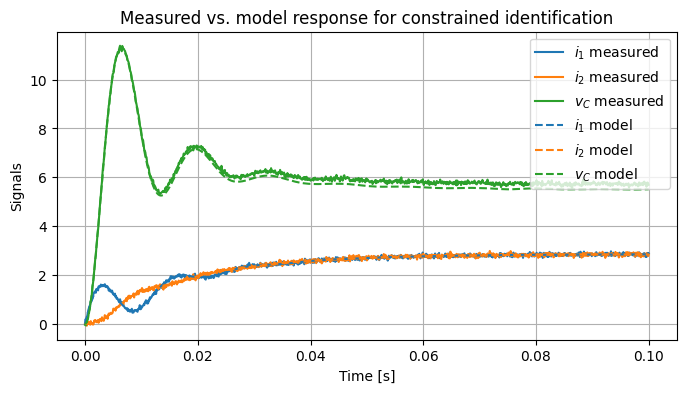

In [41]:
w_final = res_constrained.x
sol_final = solve_ivp(lambda t, x: circuit_dynamics(t, x, w_final), tspan, x0, t_eval=t_eval, vectorized=False)
x_final = sol_final.y

plt.figure(figsize=(8, 4))
plt.plot(t, y[0, :], label=r'$i_1$ measured', color='tab:blue')
plt.plot(t, y[1, :], label=r'$i_2$ measured', color='tab:orange')
plt.plot(t, y[2, :], label=r'$v_C$ measured', color='tab:green')
plt.plot(t, x_final[0, :], '--', label=r'$i_1$ model', color='tab:blue')
plt.plot(t, x_final[1, :], '--', label=r'$i_2$ model', color='tab:orange')
plt.plot(t, x_final[2, :], '--', label=r'$v_C$ model', color='tab:green')
plt.xlabel('Time [s]')
plt.ylabel('Signals')
plt.title('Measured vs. model response for constrained identification')
plt.legend()
plt.grid(True)
plt.show()